# Random Forest — Original Feature Set
---

1.   **[Introduction to Random Forest](#1.-Introduction-to-Random-Forest)**
2.   **[Foundations of Random Forest](#2.-Foundations-of-Random-Forest)**
3.   **[Random Forest Tuning](#3.-Random-Forest-Tuning)**
4.   **[Model Validation](#4.-Model-Validation)**
5.   **[Exploratory Data Analysis](#5.-Exploratory-Data-Analysis)**
6.   **[Model Construction](#6.-Model-Construction)**
7.   **[Model Results & Evaluation](#7.-Model-Results-&-Evaluation)**

---
<a name="1.-Introduction-to-Random-Forest"></a>
### 1. Introduction to Random Forest

#### 1.1 Definitions

**Random Forest |** Ensemble of decision trees trained on bootstrapped data with randomly selected features.

**Ensembling |** Aggregating predictive model outputs to make a prediction rather than relying on an individual model.

**Base Learner |** Each individual tree that comprises the ensemble.

**Regression Random Forest |** Here Random Forest is used as a **regressor** (`RandomForestRegressor`), predicting a continuous target — crop yield (Q/acre)  rather than a class label. Predictions are the average of all trees' outputs instead of a majority vote.

---
<a name="2.-Foundations-of-Random-Forest"></a>
### 2. Foundations of Random Forest

#### 2.1 Concept
Random Forest builds a bagging ensemble of decision trees and additionally randomizes the subset of features considered at each split. When mistakes between individual trees are uncorrelated, averaging their predictions reduces variance without increasing bias, which typically improves generalization over a single decision tree, especially on tabular agronomic data such as this one, where relationships between rainfall, temperature, fertilizer and yield may be non-linear and involve interactions.

---
<a name="3.-Random-Forest-Tuning"></a>
### 3. Random Forest Tuning

Random forest tuning refers to the process of adjusting the hyperparameters that control the structure of the trees, to balance underfitting and overfitting.

**Hyperparameters tuned here:**

| Hyperparameter | What it does | Values tried |
| --- | --- | --- |
| `n_estimators` | Number of trees in the forest | 100, 200 |
| `max_depth` | Maximum depth of each tree | 5, 10, None |
| `min_samples_leaf` | Minimum samples required at a leaf node | 1, 2 |
| `max_features` | Number of features considered at each split | sqrt |

---
<a name="4.-Model-Validation"></a>
### 4. Model Validation

Model validation verifies that the model performs as expected on unseen data. Two layers of validation are used here:

- **Hold-out test set (20%)**, kept untouched during tuning, used only for final evaluation.
- **5-fold cross-validation** on the full dataset, to check that performance is stable across different splits rather than a lucky/unlucky artefact of one split.

`GridSearchCV` performs its own internal 5-fold cross-validation on the training set to select hyperparameters, scored on negative RMSE.

---
<a name="5.-Exploratory-Data-Analysis"></a>
### 5. Exploratory Data Analysis

#### 5.1 Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset into a DataFrame
data = pd.read_excel("/content/Crop yield data sheet.xlsx")
data.columns = [c.strip() for c in data.columns]
data = data.rename(columns={
    'Rain Fall (mm)': 'rainfall', 'Fertilizer': 'fertilizer', 'Temperatue': 'temperature',
    'Nitrogen (N)': 'nitrogen', 'Phosphorus (P)': 'phosphorus', 'Potassium (K)': 'potassium',
    'Yeild (Q/acre)': 'yield_q_acre', 'Crop Type': 'crop_type'
})

#### 5.2 Data Exploration

In [5]:
# Display the first 5 rows of the data
data.head()

,rainfall,fertilizer,temperature,nitrogen,phosphorus,potassium,yield_q_acre,crop_type
0,1230,80,28,80,24,20,12.0,Corn
1,480,60,36,70,20,18,8.0,Sorghum
2,1250,75,29,78,22,19,11.0,Soybean
3,450,65,35,70,19,18,9.0,Sorghum
4,1200,80,27,79,22,19,11.0,Wheat


In [6]:
# Shape and dtypes
print(data.shape)
data.dtypes

(1000, 8)


,0
rainfall,int64
fertilizer,int64
temperature,int64
nitrogen,int64
phosphorus,int64
potassium,int64
yield_q_acre,float64
crop_type,object


##### 5.2.1 Check for Missing Values

In [7]:
data.isnull().sum()

,0
rainfall,0
fertilizer,0
temperature,0
nitrogen,0
phosphorus,0
potassium,0
yield_q_acre,0
crop_type,0


No missing values are present, so no imputation or row dropping is required.

##### 5.2.2 Feature Set — Original
This notebook uses the **original feature set only**: `crop_type`, `rainfall`, `temperature`, `fertilizer`, `nitrogen`, `phosphorus`, `potassium` (no engineered variables).

In [8]:
original_cols = ['crop_type', 'rainfall', 'temperature', 'fertilizer', 'nitrogen', 'phosphorus', 'potassium']
target = 'yield_q_acre'

##### 5.2.3 Encode Data
Random Forest requires numeric input, so `crop_type` is one-hot encoded (dropping the first category to avoid redundancy). No scaling is required for tree-based models.

In [9]:
X = pd.get_dummies(data[original_cols], columns=['crop_type'], drop_first=True)
y = data[target]
X.head()

,rainfall,temperature,fertilizer,nitrogen,phosphorus,potassium,crop_type_Corn,crop_type_Rice,crop_type_Sorghum,crop_type_Soybean,crop_type_Wheat
0,1230,28,80,80,24,20,True,False,False,False,False
1,480,36,60,70,20,18,False,False,True,False,False
2,1250,29,75,78,22,19,False,False,False,True,False
3,450,35,65,70,19,18,False,False,True,False,False
4,1200,27,80,79,22,19,False,False,False,False,True


##### 5.2.4 Create Training and Test Data
Same split convention as the baseline model: **20% test size, random_state=42**.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(800, 11) (200, 11)


---
<a name="6.-Model-Construction"></a>
### 6. Model Construction

#### 6.1 Tune Model

In [11]:
# Hyperparameter grid
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
}

rf = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

#### 6.2 Create Model

In [12]:
# Obtain optimal parameters
rf_grid.best_params_

{'max_depth': 5,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'n_estimators': 200}

In [13]:
rf_best = rf_grid.best_estimator_
rf_best

RandomForestRegressor(max_depth=5, max_features='sqrt', min_samples_leaf=2,
                      n_estimators=200, random_state=42)

---
<a name="7.-Model-Results-&-Evaluation"></a>
### 7. Model Results & Evaluation

#### 7.1 Predict on Train and Test Sets

In [14]:
pred_train = rf_best.predict(X_train)
pred_test = rf_best.predict(X_test)

#### 7.2 Obtain Performance Scores

In [15]:
train_mae = mean_absolute_error(y_train, pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, pred_train))
train_r2 = r2_score(y_train, pred_train)

test_mae = mean_absolute_error(y_test, pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
test_r2 = r2_score(y_test, pred_test)

print(f'Train  -> MAE: {train_mae:.3f} | RMSE: {train_rmse:.3f} | R2: {train_r2:.3f}')
print(f'Test   -> MAE: {test_mae:.3f} | RMSE: {test_rmse:.3f} | R2: {test_r2:.3f}')

Train  -> MAE: 2.170 | RMSE: 2.542 | R2: 0.184
Test   -> MAE: 2.288 | RMSE: 2.712 | R2: 0.025


#### 7.3 Five-Fold Cross-Validation

In [16]:
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = -cross_val_score(rf_best, X, y, cv=kf5, scoring='neg_root_mean_squared_error')
print(f'CV RMSE mean: {cv_rmse.mean():.3f} | CV RMSE std: {cv_rmse.std():.3f}')

CV RMSE mean: 2.751 | CV RMSE std: 0.161


#### 7.4 Evaluate Feature Importance

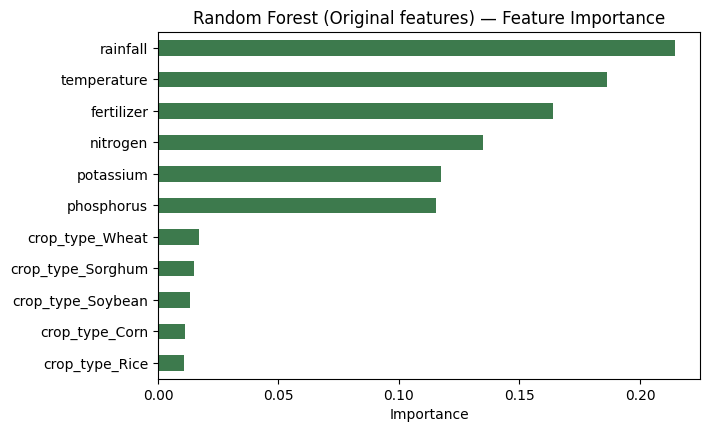

In [17]:
importances = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7,4.5))
importances.plot(kind='barh', ax=ax, color='#3d7a4d')
ax.set_xlabel('Importance')
ax.set_title('Random Forest (Original features) — Feature Importance')
plt.show()

**Reading the chart:** rainfall and temperature are the two most influential predictors, followed by fertilizer and the N-P-K macronutrients individually. The one-hot encoded crop-type dummies contribute comparatively little on their own.

```
rainfall: 0.2144
temperature: 0.1863
fertilizer: 0.1641
nitrogen: 0.135
potassium: 0.1176
phosphorus: 0.1154
crop_type_Wheat: 0.0172
crop_type_Sorghum: 0.0148
crop_type_Soybean: 0.0131
crop_type_Corn: 0.0112
crop_type_Rice: 0.0108
```

#### 7.5 Summary

| Metric | Train | Test |
| --- | --- | --- |
| MAE | 2.17 | 2.288 |
| RMSE | 2.542 | 2.712 |
| R² | 0.184 | 0.025 |

5-fold CV RMSE: **2.751 ± 0.161**

The gap between train and test R² is small, meaning the tuned model is not strongly overfitting  but overall R² remains low (~0.03), confirming that the original feature set carries only weak signal for predicting yield.